In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import requests
import json
import sklearn 
from py_clob_client import ClobClient

import asyncio
import websockets

In [ ]:
GAMMA_API = 'https://gamma-api.polymarket.com'
CLOB_API = 'https://clob.polymarket.com'

In [ ]:
def get_current_btc_5m_token_ids():
    current_time = int(time.time())
    current_interval = (current_time // 300) * 300
    slug = f"btc-updown-5m-{current_interval}"
    url = f"{GAMMA_API}/markets"
    response = requests.get(url, params={'slug': slug}).json()
    token_ids = json.loads(response[0]['clobTokenIds']) # [yes_token_id, no_token_id]
    return token_ids

In [ ]:
current_time = int(time.time())
current_interval = (current_time // 300) * 300
slug = f"btc-updown-5m-{current_interval}"
url = f"{GAMMA_API}/markets"
response = requests.get(url, params={'slug': slug}).json()
token_ids = json.loads(response[0]['clobTokenIds'])
response

[{'id': '1528112',
  'question': 'Bitcoin Up or Down - March 8, 7:10PM-7:15PM ET',
  'conditionId': '0xbcf14dd29bcea4a05f24a83ca624ca3a2e7c2aba3fcb79cb07d233b72f3f0043',
  'slug': 'btc-updown-5m-1773011400',
  'resolutionSource': 'https://data.chain.link/streams/btc-usd',
  'endDate': '2026-03-08T23:15:00Z',
  'liquidity': '58616.0708',
  'startDate': '2026-03-07T23:18:25.341352Z',
  'image': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png',
  'icon': 'https://polymarket-upload.s3.us-east-2.amazonaws.com/BTC+fullsize.png',
  'description': 'This market will resolve to "Up" if the Bitcoin price at the end of the time range specified in the title is greater than or equal to the price at the beginning of that range. Otherwise, it will resolve to "Down".\nThe resolution source for this market is information from Chainlink, specifically the BTC/USD data stream available at https://data.chain.link/streams/btc-usd.\nPlease note that this market is about the price accord

: 

In [ ]:
res = requests.get(CLOB_API + "/book", params={'token_id': get_current_btc_5m_token_ids()[0]}).json()
res

{'market': '0x2ecd9ef38c8cb85a8d536ef9281e544a468aa736e206206b2733fbfeaeb0b70f',
 'asset_id': '61531504470806867051166853062521973894399040607534267534855476296587465270849',
 'timestamp': '1773000362770',
 'hash': '1a3298bbd439ad56c41c80e0d1db4f66f21fa37a',
 'bids': [{'price': '0.01', 'size': '30266.47'},
  {'price': '0.02', 'size': '10049.16'},
  {'price': '0.03', 'size': '2811.49'},
  {'price': '0.04', 'size': '2883.75'},
  {'price': '0.05', 'size': '1175.83'},
  {'price': '0.06', 'size': '1336.65'},
  {'price': '0.07', 'size': '1662.4'},
  {'price': '0.08', 'size': '685.43'},
  {'price': '0.09', 'size': '280'},
  {'price': '0.1', 'size': '724'},
  {'price': '0.11', 'size': '971.29'},
  {'price': '0.12', 'size': '491.42'},
  {'price': '0.13', 'size': '158.32'},
  {'price': '0.14', 'size': '593.14'},
  {'price': '0.15', 'size': '195.32'},
  {'price': '0.16', 'size': '397.8'},
  {'price': '0.17', 'size': '508.88'},
  {'price': '0.18', 'size': '139.55'},
  {'price': '0.19', 'size': '22

In [ ]:
data = pd.read_parquet('data/polymarket_orderbook_2026-03-08T18.parquet')

In [ ]:
filters = [
    ('market_id', '=', '0x592c4a829557baa652fea1ff6d94bdbe97da961e58d30155114a032390621992'),
    # ('update_type', 'in', ['book_snapshot', 'price_change'])
]
data = pd.read_parquet('data/polymarket_orderbook_2026-03-08T18.parquet',
                       filters=filters)

In [ ]:
data.sort_values('timestamp_received')

,timestamp_received,timestamp_created_at,market_id,update_type,data
122,2026-03-08 18:00:06.499000+00:00,2026-03-08 18:00:06.550000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
123,2026-03-08 18:00:06.499000+00:00,2026-03-08 18:00:06.550000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
124,2026-03-08 18:00:08.341000+00:00,2026-03-08 18:00:08.383000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
125,2026-03-08 18:00:08.341000+00:00,2026-03-08 18:00:08.383000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
127,2026-03-08 18:02:34.039000+00:00,2026-03-08 18:02:34.084000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
...,...,...,...,...,...
117,2026-03-08 18:59:57.970000+00:00,2026-03-08 18:59:58.007000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
118,2026-03-08 18:59:58.049000+00:00,2026-03-08 18:59:58.110000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
119,2026-03-08 18:59:58.049000+00:00,2026-03-08 18:59:58.110000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."
120,2026-03-08 18:59:58.127000+00:00,2026-03-08 18:59:58.175000+00:00,0x592c4a829557baa652fea1ff6d94bdbe97da961e58d3...,price_change,"{""update_type"": ""price_change"", ""market_id"": ""..."


In [ ]:
book_snapshot = data.query('update_type == "book_snapshot"').iloc[1]['data']
book_snapshot = json.loads(book_snapshot)

In [ ]:
bids_snapshot = pd.DataFrame(book_snapshot['bids'], columns=['price', 'size'], dtype=float).sort_values('price', ascending=False)
asks_snapshot = pd.DataFrame(book_snapshot['asks'], columns=['price', 'size'], dtype=float)
asks_snapshot['price'] = pd.to_numeric(asks_snapshot['price'])
asks_snapshot['size'] = pd.to_numeric(asks_snapshot['size'])
bids_snapshot['price'] = pd.to_numeric(bids_snapshot['price'])
bids_snapshot['size'] = pd.to_numeric(bids_snapshot['size'])

# Feature extraction:

In [ ]:
def get_order_imbalance_at_price_level(df_books, price_level):
    bid_volume = df_books.query("order_type == 'bid'").groupby('timestamp').apply(lambda x: x.nlargest(5, 'price')['size'].sum(), include_groups=False)
    ask_volume = df_books.query("order_type == 'ask'").groupby('timestamp').apply(lambda x: x.nsmallest(5, 'price')['size'].sum(), include_groups=False)
    imbalance = (bid_volume - ask_volume) / (bid_volume + ask_volume)
    return imbalance

In [ ]:
sample_msg = {
  "event_type": "book",
  "asset_id": "65818619657568813474341868652308942079804919287380422192892211131408793125422",
  "market": "0xbd31dc8a20211944f6b70f31557f1001557b59905b7738480ca09bd4532f84af",
  "bids": [
    { "price": ".48", "size": "30" },
    { "price": ".49", "size": "20" },
    { "price": ".50", "size": "15" }
  ],
  "asks": [
    { "price": ".52", "size": "25" },
    { "price": ".53", "size": "60" },
    { "price": ".54", "size": "10" }
  ],
  "timestamp": "123456789000",
  "hash": "0x0...."
}

prx_change = {
  "market": "0x5f65177b394277fd294cd75650044e32ba009a95022d88a0c1d565897d72f8f1",
  "price_changes": [
    {
      "asset_id": "71321045679252212594626385532706912750332728571942532289631379312455583992563",
      "price": "0.5",
      "size": "200",
      "side": "BUY",
      "hash": "56621a121a47ed9333273e21c83b660cff37ae50",
      "best_bid": "0.5",
      "best_ask": "1"
    }
  ],
  "timestamp": "1757908892351",
  "event_type": "price_change"
}

bids_snapshot = pd.DataFrame(sample_msg['bids'], columns=['price', 'size'], dtype=np.float32).sort_values('price', ascending=False)
bids_snapshot['timestamp'] = int(sample_msg['timestamp'])
bids_snapshot['market_id'] = sample_msg['market']

asks_snapshot = pd.DataFrame(sample_msg['asks'], columns=['price', 'size'], dtype=np.float32)
asks_snapshot['timestamp'] = int(sample_msg['timestamp'])
asks_snapshot['market_id'] = sample_msg['market']

In [ ]:
bids_snapshot.loc[bids_snapshot['price'] == float('0.5'), 'size'] = 200

In [ ]:
# Read pickled book data
df = pd.read_pickle('raw_book_data/book-btc-updown-5m-1773186600.pkl')

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
df[['price', 'size']] = df[['price', 'size']].transform(lambda s: pd.to_numeric(s))
df.rename_axis(index='index', inplace=True)

# Keep only latest timestamps within same 1 second interval
max_ts = df['timestamp'].groupby(df['timestamp'].dt.floor('s')).transform('max')
df = df[df['timestamp'] == max_ts]

In [ ]:
df

,price,size,timestamp,order_type,btc_price,price_to_beat
0,0.99,10925.98,1773186600007,ask,69892.95,NaN
1,0.98,8135.04,1773186600007,ask,69892.95,NaN
2,0.97,647.94,1773186600007,ask,69892.95,NaN
3,0.96,4710.00,1773186600007,ask,69892.95,NaN
4,0.95,405.04,1773186600007,ask,69892.95,NaN
...,...,...,...,...,...,...
66,0.04,4961.08,1773186900041,bid,69901.61,NaN
67,0.03,1225.33,1773186900041,bid,69901.61,NaN
68,0.02,8614.77,1773186900041,bid,69901.61,NaN
69,0.01,6541.76,1773186900041,bid,69901.61,NaN


In [ ]:
df_books = df

bid_volume = df_books.query("order_type == 'bid'").groupby('timestamp').apply(lambda x: x.nlargest(5, 'price')['size'].sum(), include_groups=False)
ask_volume = df_books.query("order_type == 'ask'").groupby('timestamp').apply(lambda x: x.nsmallest(5, 'price')['size'].sum(), include_groups=False)
bid_vol, ask_vol = bid_volume.align(ask_volume, join='outer', axis=0, fill_value=0)
imbalance = (bid_vol - ask_vol) / (bid_vol + ask_vol)

In [ ]:
imbalance

timestamp
2026-03-09 18:04:59.752   -1.000000
2026-03-09 18:05:00.941    0.023380
2026-03-09 18:05:01.999    0.210484
2026-03-09 18:05:02.948    0.127603
2026-03-09 18:05:03.832    0.207751
                             ...   
2026-03-09 18:09:53.897   -1.000000
2026-03-09 18:09:54.933   -1.000000
2026-03-09 18:09:55.972   -0.996467
2026-03-09 18:09:56.270   -1.000000
2026-03-09 18:09:59.510   -1.000000
Length: 295, dtype: float64

In [ ]:
res = requests.get("https://gamma-api.polymarket.com"+"/markets", params={'slug': 'btc-updown-5m-1773184500'})
res.json()[0]['events'][0]['eventMetadata']['priceToBeat']

69804.13599572395

In [ ]:
GAMMA_API = "https://gamma-api.polymarket.com"
def get_token_ids_by_slug(slug, return_res=False):
    # Gamma API handles market discovery
    url = f"{GAMMA_API}/markets"
    response = requests.get(url, params={'slug': slug}).json()

    # clobTokenIds is a list: index 0 is YES, index 1 is NO
    token_ids = json.loads(response[0]['clobTokenIds'])
    if return_res:
        return token_ids, response
    return token_ids

token_ids, res = get_token_ids_by_slug('btc-updown-5m-1773186900', True)

# Feature extraction and regression

In [ ]:
import joblib
pipeline = joblib.load('model_log_ret.joblib')

In [2]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from feature_pipeline import *
DATA_DIR    = 'raw_book_data'
N_LEVELS    = 5
HORIZON_MS  = 5000
DOWNSAMPLE  = 1000

# feat = build_pipeline(data_dir=DATA_DIR, n_levels=N_LEVELS,
#                         horizon_ms=HORIZON_MS, downsample_ms=DOWNSAMPLE,
#                         mean=True)
# all_target_cols = [c for c in feat.columns if c.startswith('target_')]
# target_cols = sorted(
#         [c for c in all_target_cols if not c.startswith('target_diff_')],
#         key=lambda c: int(c.split('_')[1].rstrip('s'))
#     )

# feat_cols = [c for c in feat.columns if c not in set(all_target_cols)]

# clean = feat[feat_cols + target_cols].dropna()
# train_clean = clean[clean.index < 1773340800000]
# test_clean = clean[clean.index >= 1773340800000]
# X_tr = train_clean[feat_cols].values
# Y_tr = train_clean[target_cols].values  # shape (n_samples, n_steps)
# X_te = test_clean[feat_cols].values
# Y_te = test_clean[target_cols].values  # shape (n_samples, n_steps)

In [181]:
# Load raw data
raw_data = load_raw_books()

# Get orderbook features (Do i need to refactor this?)
feat = extract_features(raw_data) 

Loading 69 file(s)...


In [183]:
feat.to_pickle('raw_extracted_features.pkl')

In [184]:
# Transform mid price to logit space (Should I be doing this before or after downsampling? Shouldn't matter I think?)
# Perhaps should be doing this before running extract_features? Converting the price column to logit space first perhaps?
def logit(x):
    x_clipped = np.clip(x, 1e-6, 1-1e-6)
    logits = np.log(1 / (1-x_clipped))
    return logits

feat['mid'] = logit(feat['mid'])

In [185]:
# Downsample 1s intervals
filter_1s = feat.index // 1000
MAX_MIN_COLS = ['best_bid', 'best_ask', 'mid', 'ask_vol_all', 'bid_vol_all']
AVE_COLS = []
downsamp_feat = feat.groupby(filter_1s).last()  # Get last point in each interval for (all features)
downsamp_maxmin = feat.groupby(filter_1s)[MAX_MIN_COLS].agg(['max', 'min']) # Get max and min in each interval
downsamp_maxmin.columns = ['_'.join(col) for col in downsamp_maxmin.columns.values]
downsamp_feat = pd.concat([downsamp_maxmin, downsamp_feat], axis=1)

# Add Order Flow Imbalance feature:
downsamp_feat['ofi'] = downsamp_feat['bid_vol'].diff(1) - downsamp_feat['ask_vol'].diff(1)

# Add target columns (return)
PRED_WINDOW = 5
downsamp_feat['return'] = downsamp_feat['mid'].shift(-PRED_WINDOW) - downsamp_feat['mid']
# downsamp_feat['max_return'] = downsamp_feat['mid_max'].shift(-PRED_WINDOW) - downsamp_feat['mid']
# downsamp_feat['min_return'] = downsamp_feat['mid_min'].shift(-PRED_WINDOW) - downsamp_feat['mid']

# Add time-lagged + rolling average features
LAGGED_COLS = ['best_bid', 'best_ask', 'mid', 
               'best_bid_max', 'best_ask_max', 'mid_max', 
               'best_bid_min', 'best_ask_min', 'mid_min', 'ofi']
LAGS = [1,2,3,4,5]
ROLL_AVE_COLS = ['mid', 'spread', 'vwap', 'best_bid', 'best_ask', 'rel_spread']
ROLL_WINDOWS = [3,4,5]

# Add lagged features
for lag in LAGS:
    lagged_feats = downsamp_feat[LAGGED_COLS].shift(lag).rename(columns=lambda x: x+f'_lag{lag}')
    downsamp_feat = pd.concat([downsamp_feat, lagged_feats], axis=1)

# Add rolling ave features
for w in ROLL_WINDOWS:
    ave_feats = downsamp_feat[ROLL_AVE_COLS].rolling(w).mean().rename(columns=lambda x: x+f'_ave{w}')
    downsamp_feat = pd.concat([downsamp_feat, ave_feats], axis=1)

# Add temporal features
downsamp_feat['time_in_interval'] = downsamp_feat.index % 300
downsamp_feat['time_since_midnight'] = downsamp_feat.index % 86400

In [ ]:
# Define model and pipeline
model = RandomForestRegressor(n_estimators=100, criterion='squared_error', random_state=42)
model = MultiOutputRegressor(model, n_jobs=-1)

# TODO: Add Column Transformer to exclude time_of_day feature from MinMaxScaling
pipeline = Pipeline([('scaler', MinMaxScaler()), ('model', model)])

In [186]:
from xgboost import XGBRegressor

quantiles = [0.1, 0.5, 0.9]
models = {q: Pipeline([('scaler', MinMaxScaler()), 
                       ('model', XGBRegressor(objective='reg:quantileerror', quantile_alpha=q, 
                                              n_estimators=100, random_state=42))])
          for q in quantiles}

TARGET_COLS = ['return'] #, 'max_return', 'min_return']
clean = downsamp_feat.dropna()
X = clean.drop(columns=TARGET_COLS).values
y = clean[TARGET_COLS].values

tscv = TimeSeriesSplit(n_splits=5)
print(f'\n--- TimeSeriesSplit CV (5 folds) ---')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    pb_losses = {}
    for q in quantiles:
        models[q].fit(X[tr_idx], y[tr_idx])
        y_pred = models[q].predict(X[val_idx])
        y_val = y[val_idx]

        err = y_val - y_pred
        loss = float(np.mean(np.where(err >= 0, q * err, (q - 1) * err)))
        pb_losses[q] = loss

    print(f'  Fold {fold+1}: PBL_10={pb_losses[0.1]:.6f}  PBL_50={pb_losses[0.5]:.6f}  PBL_90={pb_losses[0.9]:.6f}'
        f'(n_train={len(tr_idx):,}  n_val={len(val_idx):,})')    

    # pipeline.fit(X[tr_idx], y[tr_idx])
    # preds = pipeline.predict(X[val_idx])
    # y_val = y[val_idx]

    # mae = np.mean(np.abs(y_val - preds))
    # mse = np.mean((y_val - preds)**2)
    # r2 = r2_score(y_val, preds)
    # print(f'  Fold {fold+1}: MAE={mae:.6f}  MSE=[{mse}]  R^2={r2}'
            # f'(n_train={len(tr_idx):,}  n_val={len(val_idx):,})')


--- TimeSeriesSplit CV (5 folds) ---
  Fold 1: PBL_10=0.087325  PBL_50=0.126605  PBL_90=0.097287(n_train=3,387  n_val=3,384)
  Fold 2: PBL_10=0.097908  PBL_50=0.134644  PBL_90=0.108211(n_train=6,771  n_val=3,384)
  Fold 3: PBL_10=0.085493  PBL_50=0.126525  PBL_90=0.093868(n_train=10,155  n_val=3,384)
  Fold 4: PBL_10=0.158438  PBL_50=0.233277  PBL_90=0.166783(n_train=13,539  n_val=3,384)
  Fold 5: PBL_10=0.122083  PBL_50=0.178949  PBL_90=0.136891(n_train=16,923  n_val=3,384)


In [189]:
# Re-fit on whole dataset
pred_returns = {}
pred_quantiles = {}
for q in quantiles:
    models[q].fit(X[:-300], y[:-300])
    pred_returns[q] = models[q].predict(X)
    pred_quantiles[q] = (clean['mid'] + pred_returns[q]).shift(PRED_WINDOW)

    # Transform back to price-space:
    pred_quantiles[q] = pred_quantiles[q].apply(lambda x: 1 / (1 + np.exp(-x)))

# Results Analysis

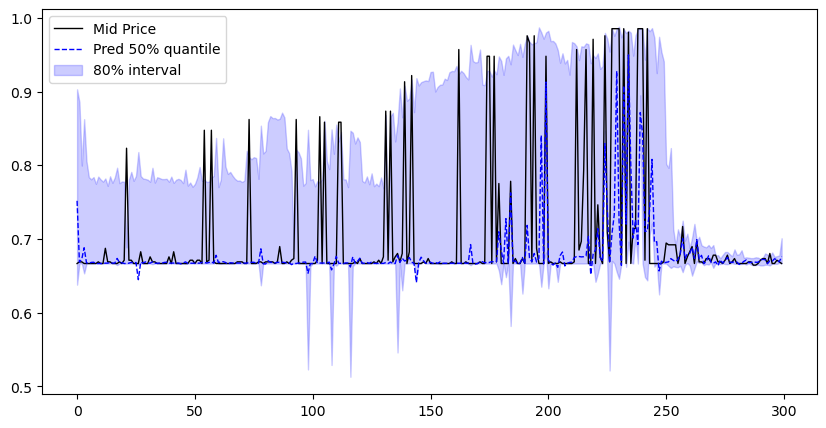

In [190]:
# Convert back to price-space:
actual = clean['mid'].apply(lambda x: 1 / (1 + np.exp(-x)))

# Plotting results
IDX = 44
WINDOW = 300
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(
    actual.values[IDX*WINDOW:(IDX+1)*WINDOW], 
    linewidth=1, color='black', label='Mid Price')
plt.plot(
    pred_quantiles[0.5].values[IDX*WINDOW:(IDX+1)*WINDOW], 
    linestyle='--', linewidth=1, color='blue', label='Pred 50% quantile')
plt.fill_between(
    list(range(WINDOW)), 
    pred_quantiles[0.1].values[IDX*WINDOW:(IDX+1)*WINDOW], 
    pred_quantiles[0.9].values[IDX*WINDOW:(IDX+1)*WINDOW], 
    alpha=0.2, color='blue', label="80% interval")
plt.legend()

In [191]:
# Computing other diagnostics
within_80_interval = (actual.values[10:] >= pred_quantiles[0.1].values[10:]) & \
    ((actual.values[10:] <= pred_quantiles[0.9].values[10:]))
coverage = np.mean(within_80_interval)
coverage_90 = np.mean(actual.values[10:] <= pred_quantiles[0.9].values[10:])
coverage_10 = np.mean(actual.values[10:] <= pred_quantiles[0.1].values[10:])
directional_acc = np.mean(np.sign(clean['return']).values == np.sign(pred_returns[0.5]))
print(f"80% interval coverage: {coverage}")
print(f"90% quantile coverage: {coverage_90}")
print(f"10% quantile coverage: {coverage_10}")
print(f"Directional accuracy of median: {directional_acc}")

# Computing other diagnostics
within_80_interval = (actual.values[-300:] >= pred_quantiles[0.1].values[-300:]) & \
    ((actual.values[-300:] <= pred_quantiles[0.9].values[-300:]))
coverage = np.mean(within_80_interval)
coverage_90 = np.mean(actual.values[-300:] <= pred_quantiles[0.9].values[-300:])
coverage_10 = np.mean(actual.values[-300:] <= pred_quantiles[0.1].values[-300:])
directional_acc = np.mean(np.sign(clean['return']).values[-300:] == np.sign(pred_returns[0.5][-300:]))
print(f"80% interval coverage: {coverage}")
print(f"90% quantile coverage: {coverage_90}")
print(f"10% quantile coverage: {coverage_10}")
print(f"Directional accuracy of median: {directional_acc}")

80% interval coverage: 0.7964723850815392
90% quantile coverage: 0.8980637532640292
10% quantile coverage: 0.1019855151007538
Directional accuracy of median: 0.6593292953168858
80% interval coverage: 0.66
90% quantile coverage: 0.81
10% quantile coverage: 0.15
Directional accuracy of median: 0.6333333333333333


In [192]:
# Feature importances
pd.DataFrame({'importances': models[0.5].named_steps['model'].feature_importances_}, 
             index=clean.columns.drop(TARGET_COLS)).sort_values('importances', ascending=False)

,importances
best_ask_max,0.312410
mid,0.270673
time_in_interval,0.023425
ask_n_levels,0.019179
spread,0.016294
...,...
best_ask_min_lag3,0.002218
mid_max_lag5,0.002207
ask_vol_all_max,0.002126
best_bid_max_lag2,0.001591


In [ ]:
def pit_value(series):
    y = series['mid']
    q10 = series[0.1]
    q50 = series[0.5]
    q90 = series[0.9]
    if y <= q10:
        return 0.1 * (y / q10)
    elif y <= q50:
        return 0.1 + 0.4 * (y - q10) / (q50 - q10)
    elif y <= q90:
        return 0.5 + 0.4 * (y - q50) / (q90 - q50)
    else:
        return 0.9 + 0.1 * (y - q90) / (1 - q90)
    
result_df = pd.concat([actual, pd.DataFrame(pred_quantiles)], axis=1)
pit_vals = result_df.apply(pit_value, axis=1)

In [180]:
result_df.iloc[0][0.1]

np.float64(nan)

<Axes: >

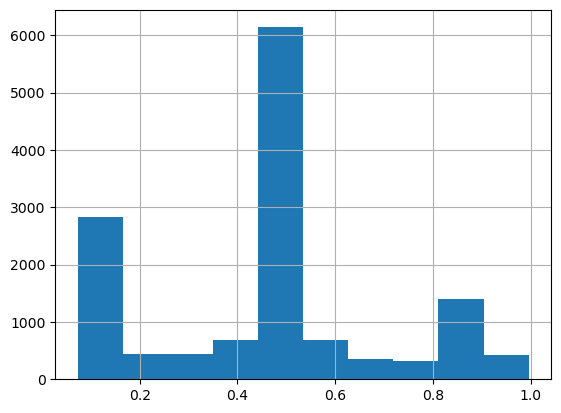

In [176]:
pit_vals.hist()

In [ ]:
pipeline.fit(X[:-300], y[:-300])
preds = pipeline.predict(X)
mid_pred = (clean['mid'] + preds[:, 1]).shift(10)
max_mid_pred = (clean['mid'] + preds[:, 0]).shift(10)  
min_mid_pred = (clean['mid'] + preds[:, 2]).shift(10)

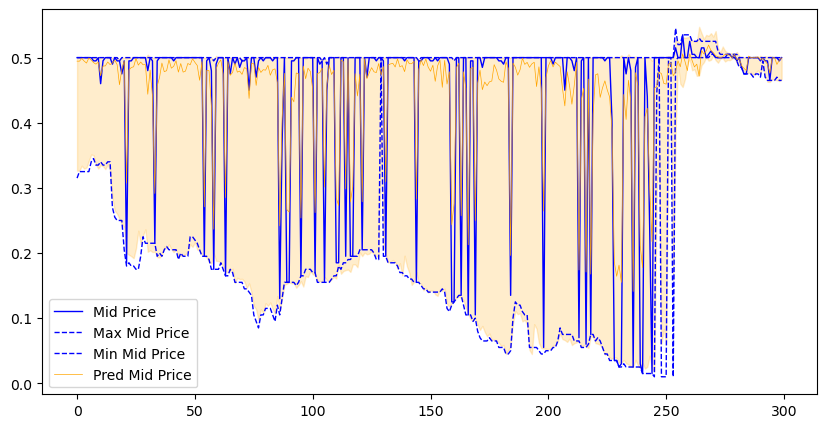

In [ ]:
IDX = 42
WINDOW = 300
fig, ax = plt.subplots(figsize=(10, 5))
plt.fill_between(
    list(range(300)), 
    max_mid_pred.values[IDX*WINDOW:(IDX+1)*WINDOW], 
    min_mid_pred.values[IDX*WINDOW:(IDX+1)*WINDOW], 
    alpha=0.2, color='orange')
plt.plot(
    clean['mid'].values[IDX*WINDOW:(IDX+1)*WINDOW], 
    linewidth=1, label='Mid Price', color='blue')
plt.plot(
    clean['mid_max'].values[IDX*WINDOW:(IDX+1)*WINDOW], 
    linestyle='--', linewidth=1, label='Max Mid Price', color='blue')
plt.plot(
    clean['mid_min'].values[IDX*WINDOW:(IDX+1)*WINDOW], 
    linestyle='--', linewidth=1, label='Min Mid Price', color='blue')
plt.plot(
    mid_pred.values[IDX*WINDOW:(IDX+1)*WINDOW], 
    linewidth=0.5, label='Pred Mid Price', color='orange')
plt.legend()

In [68]:
import feature_pipeline as fp
feat_cols = ['mid', 'best_bid', 'best_ask', 'microprice', 'vwap', 'mid_imax', 'best_bid_imax', 'best_ask_imax', 'microprice_imax', 'vwap_imax', 'mid_imin', 'best_bid_imin', 'best_ask_imin', 'microprice_imin', 'vwap_imin', 'mid_istd', 'best_bid_istd', 'best_ask_istd', 'microprice_istd', 'vwap_istd', 'bid_vol', 'ask_vol', 'bid_vol_all', 'ask_vol_all', 'bid_n_levels', 'ask_n_levels', 'bid_size_L1', 'bid_size_L2', 'bid_size_L3', 'bid_size_L4', 'bid_size_L5', 'ask_size_L1', 'ask_size_L2', 'ask_size_L3', 'ask_size_L4', 'ask_size_L5', 'btc_price', 'spread', 'rel_spread', 'imbalance', 'imbalance_all', 'micro_minus_mid', 'time_in_interval_s', 'time_of_day_s', 'btc_price_from_open', 'ofi', 'mid_lag0', 'mid_lag1', 'mid_lag2', 'mid_lag3', 'mid_lag4', 'mid_lag5', 'mid_lag6', 'mid_lag7', 'mid_lag8', 'mid_lag9', 'spread_lag0', 'spread_lag1', 'spread_lag2', 'spread_lag3', 'spread_lag4', 'spread_lag5', 'spread_lag6', 'spread_lag7', 'spread_lag8', 'spread_lag9', 'rel_spread_lag0', 'rel_spread_lag1', 'rel_spread_lag2', 'rel_spread_lag3', 'rel_spread_lag4', 'rel_spread_lag5', 'rel_spread_lag6', 'rel_spread_lag7', 'rel_spread_lag8', 'rel_spread_lag9', 'imbalance_lag0', 'imbalance_lag1', 'imbalance_lag2', 'imbalance_lag3', 'imbalance_lag4', 'imbalance_lag5', 'imbalance_lag6', 'imbalance_lag7', 'imbalance_lag8', 'imbalance_lag9', 'imbalance_all_lag0', 'imbalance_all_lag1', 'imbalance_all_lag2', 'imbalance_all_lag3', 'imbalance_all_lag4', 'imbalance_all_lag5', 'imbalance_all_lag6', 'imbalance_all_lag7', 'imbalance_all_lag8', 'imbalance_all_lag9', 'microprice_lag0', 'microprice_lag1', 'microprice_lag2', 'microprice_lag3', 'microprice_lag4', 'microprice_lag5', 'microprice_lag6', 'microprice_lag7', 'microprice_lag8', 'microprice_lag9', 'micro_minus_mid_lag0', 'micro_minus_mid_lag1', 'micro_minus_mid_lag2', 'micro_minus_mid_lag3', 'micro_minus_mid_lag4', 'micro_minus_mid_lag5', 'micro_minus_mid_lag6', 'micro_minus_mid_lag7', 'micro_minus_mid_lag8', 'micro_minus_mid_lag9', 'bid_vol_lag0', 'bid_vol_lag1', 'bid_vol_lag2', 'bid_vol_lag3', 'bid_vol_lag4', 'bid_vol_lag5', 'bid_vol_lag6', 'bid_vol_lag7', 'bid_vol_lag8', 'bid_vol_lag9', 'ask_vol_lag0', 'ask_vol_lag1', 'ask_vol_lag2', 'ask_vol_lag3', 'ask_vol_lag4', 'ask_vol_lag5', 'ask_vol_lag6', 'ask_vol_lag7', 'ask_vol_lag8', 'ask_vol_lag9', 'btc_price_lag0', 'btc_price_lag1', 'btc_price_lag2', 'btc_price_lag3', 'btc_price_lag4', 'btc_price_lag5', 'btc_price_lag6', 'btc_price_lag7', 'btc_price_lag8', 'btc_price_lag9', 'btc_price_from_open_lag0', 'btc_price_from_open_lag1', 'btc_price_from_open_lag2', 'btc_price_from_open_lag3', 'btc_price_from_open_lag4', 'btc_price_from_open_lag5', 'btc_price_from_open_lag6', 'btc_price_from_open_lag7', 'btc_price_from_open_lag8', 'btc_price_from_open_lag9', 'vwap_lag0', 'vwap_lag1', 'vwap_lag2', 'vwap_lag3', 'vwap_lag4', 'vwap_lag5', 'vwap_lag6', 'vwap_lag7', 'vwap_lag8', 'vwap_lag9', 'ofi_lag0', 'ofi_lag1', 'ofi_lag2', 'ofi_lag3', 'ofi_lag4', 'ofi_lag5', 'ofi_lag6', 'ofi_lag7', 'ofi_lag8', 'ofi_lag9', 'mid_diff1', 'mid_diff5', 'spread_diff1', 'spread_diff5', 'imbalance_diff1', 'imbalance_diff5', 'mid_rmean5', 'mid_rstd5', 'mid_rmean10', 'mid_rstd10', 'mid_rmean20', 'mid_rstd20', 'imbalance_rmean5', 'imbalance_rstd5', 'imbalance_rmean10', 'imbalance_rstd10', 'imbalance_rmean20', 'imbalance_rstd20', 'spread_rmean5', 'spread_rstd5', 'spread_rmean10', 'spread_rstd10', 'spread_rmean20', 'spread_rstd20']
imp = pipeline.named_steps['model'].estimators_[1].feature_importances_
pd.DataFrame({'importances': imp}, index=clean.columns.drop(TARGET_COLS)).sort_values('importances', ascending=False)

,importances
mid,0.397942
best_ask_max,0.027973
time_since_midnight,0.022739
time_in_interval,0.018324
ask_size_L4,0.016101
...,...
best_ask_min_lag3,0.001480
mid_max_lag2,0.001460
mid_max_lag3,0.001459
best_bid_max_lag2,0.001458


In [ ]:
raw_data.sort_index()

,best_bid,best_ask,bid_vol,ask_vol,bid_vol_all,ask_vol_all,bid_n_levels,ask_n_levels,bid_size_L1,bid_size_L2,...,ask_size_L5,btc_price,vwap,mid,spread,rel_spread,imbalance,imbalance_all,microprice,micro_minus_mid
timestamp,,,,,,,,,,,,,,,,,,,,,
1773186600007,0.99,0.01,109847.88,109847.88,139501.98,143560.59,26.0,70.0,104964.25,4825.04,...,41.00,69892.95,0.500970,0.5,-0.98,-1.96,0.000000,-0.014338,0.500000,-2.275957e-15
1773186600009,0.99,0.01,109842.88,109842.88,139496.98,143555.59,26.0,70.0,104964.25,4820.04,...,41.00,69892.95,0.500970,0.5,-0.98,-1.96,0.000000,-0.014339,0.500000,-2.275957e-15
1773186600016,0.99,0.01,111092.88,111092.88,140746.98,144805.59,26.0,70.0,106214.25,4820.04,...,41.00,69892.95,0.500961,0.5,-0.98,-1.96,0.000000,-0.014213,0.500000,-2.220446e-15
1773186600022,0.99,0.01,111092.88,111092.88,140646.98,144505.59,25.0,67.0,106214.25,4820.04,...,41.00,69892.95,0.500990,0.5,-0.98,-1.96,0.000000,-0.013532,0.500000,-2.220446e-15
1773186600023,0.99,0.01,111097.93,111097.93,140652.03,144510.64,25.0,67.0,106219.30,4820.04,...,41.00,69892.95,0.500990,0.5,-0.98,-1.96,0.000000,-0.013531,0.500000,-2.220446e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1773341099966,0.99,0.01,126630.45,123255.65,139182.96,155210.37,6.0,99.0,115495.48,6213.00,...,849.82,69924.69,0.509443,0.5,-0.98,-1.96,0.013505,-0.054442,0.493382,-6.617623e-03
1773341099968,0.99,0.01,127180.45,123805.65,139732.96,155760.37,6.0,99.0,116045.48,6213.00,...,849.82,69924.69,0.509408,0.5,-0.98,-1.96,0.013446,-0.054239,0.493411,-6.588620e-03
1773341099969,0.99,0.01,127185.45,123810.65,139737.96,155765.37,6.0,99.0,116045.48,6218.00,...,849.82,69924.69,0.509407,0.5,-0.98,-1.96,0.013446,-0.054238,0.493412,-6.588357e-03


In [ ]:
agg_mid = raw_data.groupby(raw_data.index // 1000)['mid'].agg(['max', 'min', 'mean', 'last'])
agg_best_bid = raw_data.groupby(raw_data.index // 1000)['best_bid'].agg(['max', 'min', 'mean', 'last'])
agg_best_ask = raw_data.groupby(raw_data.index // 1000)['best_ask'].agg(['max', 'min', 'mean', 'last'])

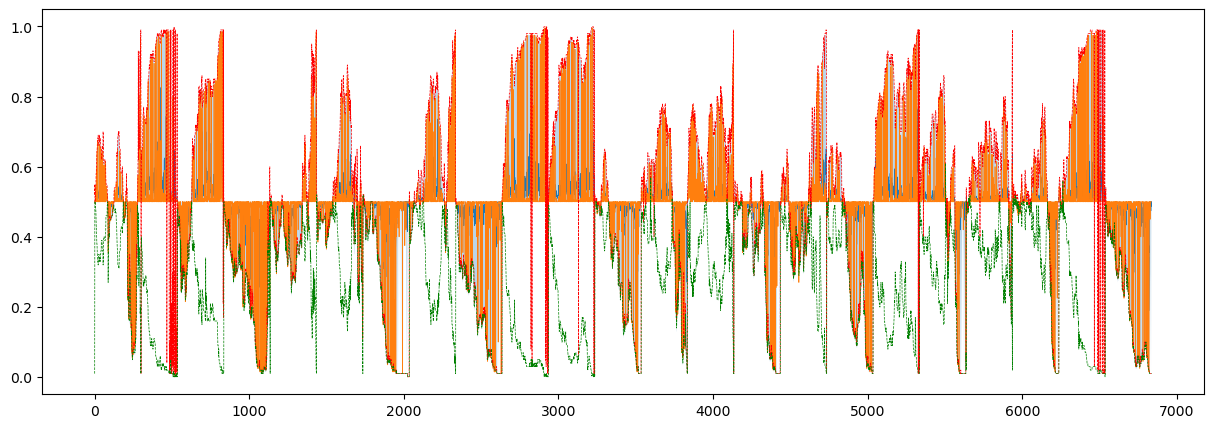

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
from_ts = 0
end_ts = None
ax.fill_between(list(range(len(agg_mid.iloc[from_ts:end_ts]))), 
                agg_mid.iloc[from_ts:end_ts]['max'], 
                agg_mid.iloc[from_ts:end_ts]['min'], alpha=0.3)

ax.plot(list(range(len(agg_mid.iloc[from_ts:end_ts]))), 
        agg_mid[from_ts:end_ts]['mean'], linewidth=0.5)

ax.plot(list(range(len(agg_mid.iloc[from_ts:end_ts]))), 
        agg_mid.iloc[from_ts:end_ts]['last'], linewidth=0.5)

ax.plot(list(range(len(agg_best_bid.iloc[from_ts:end_ts]))), 
        agg_best_ask.iloc[from_ts:end_ts]['max'], linewidth=0.5, c='red', linestyle='--')

ax.plot(list(range(len(agg_best_bid.iloc[from_ts:end_ts]))), 
        agg_best_ask.iloc[from_ts:end_ts]['min'], linewidth=0.5, c='green', linestyle='--')